In [38]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm


In [39]:
def sigma_fn(t):
    #"""Compute variance of the diffusion process
    # from variance of a gaussian mixture                           
    # w1 * sigma_1**2 + w2 * sigma_2**2  + [w1 * mu1**2 + w2 * mu2**2  - (w1 * mu1 + w2 * mu2)**2]
    
    result = 1e-5 + ((torch.exp(2*t) - 1)/2 )
    #print("sigma_fn output requires grad:", result.requires_grad)
    return  result

# diffusion coefficient
def diffusion(t):
 
    return torch.exp(t)

# adding noise to original distribution proportional to  time t
def sample_pt(x0, t):
    variance = sigma_fn(t)
    noise = torch.sqrt(variance) * torch.randn_like(x0, requires_grad=True, device=x0.device)
    return x0 + noise 


In [40]:
def prepare_fashion_mnist_data(batch_size=128, data_dir='./data', subset_size = None):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])
    
    # Load dataset
    full_dataset = datasets.FashionMNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

    # Create a smaller subset
    if subset_size and subset_size < len(full_dataset):
        # Get indices for the subset
        indices = torch.randperm(len(full_dataset))[:subset_size]
        subset_dataset = torch.utils.data.Subset(full_dataset, indices)
    else:
        subset_dataset = full_dataset
    
    # Split into train, validation, test
    train_size = int(0.7 * len(subset_dataset))
    val_size = int(0.15 * len(subset_dataset))
    test_size = len(subset_dataset) - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = random_split(
        subset_dataset, [train_size, val_size, test_size]
    )
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [41]:
def score_matching_loss(net, x0, eps=1e-5, M=1):
    batch_size = x0.shape[0]
    
    # Keep image shape [batch_size, 1, 28, 28] 
    
    # Random time points [batch_size, 1]
    t = torch.rand(size=(batch_size, 1)) * (1. - eps) + eps
    
    # Sample x_t (noise is added in the original image space)
    var = (torch.exp(2*t) - 1)/2
    noise = torch.randn_like(x0) * torch.sqrt(var).view(-1, 1, 1, 1)
    x_t = x0 + noise
    x_t.requires_grad_(True)
    
    # Predicted score s_m(x;theta) - now needs both x_t and t
    score_pred = net(x_t, t)
    
    # For sliced score matching with vectors in image space
    v = torch.randn_like(x_t)
    v = v / torch.linalg.vector_norm(v, dim=(1,2,3), keepdim=True)
    
    gradv = torch.sum(score_pred * v)
    loss1 = torch.sum(score_pred * v, dim=-1) ** 2 * 0.5
    
    grad2 = torch.autograd.grad(gradv, x_t, create_graph=True)[0]
    loss2 = torch.sum(v * grad2, dim=-1)

    loss1 = loss1.view(M, -1).mean(dim=0)
    loss2 = loss2.view(M, -1).mean(dim=0)
    
    loss = loss1.mean() + loss2.mean()
    return loss

In [42]:
class ConvScoreNetwork(nn.Module):
    def __init__(self, image_size=28, channels=1, hidden_dim=64):
        super().__init__()
        self.image_size = image_size
        
        # Time embedding
        time_embed_dim = hidden_dim
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )
        
        # Initial convolution (preserves spatial dimensions)
        self.conv1 = nn.Conv2d(channels, hidden_dim, kernel_size=3, padding=1)
        
        # Middle convolutional blocks
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.SiLU()
        )
        
        # Final convolution to output channels
        self.final = nn.Conv2d(hidden_dim, channels, kernel_size=3, padding=1)
        
    def forward(self, x, t):
        # Input x shape: [batch, channels, height, width]
        # Input t shape: [batch, 1]
        
        # Embed time and reshape for broadcasting
        t_embed = self.time_embed(t)  # [batch, time_embed_dim]
        t_embed = t_embed.view(-1, t_embed.shape[1], 1, 1)  # [batch, time_embed_dim, 1, 1]
        
        # Initial convolution
        h = self.conv1(x)  # [batch, hidden_dim, height, width]
        
        # Add time embedding to each spatial location
        h = h + t_embed.expand(-1, -1, h.shape[2], h.shape[3])
        
        # Process through convolutional blocks
        h = self.conv_blocks(h)
        
        # Final layer to predict score
        score = self.final(h)
        
        return score
    

def train_model(score_model, train_loader, val_loader, n_epochs, lr=1e-3):
    optimizer = torch.optim.Adamax(score_model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in tqdm(range(n_epochs)):
        # Training phase
        score_model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        for batch in train_loader:
            x0 = batch[0]  # Now it's [batch, 1, 28, 28]
            loss = score_matching_loss(score_model, x0, eps=1e-5)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1

        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        score_model.eval()
        #with torch.no_grad():
        val_loss = 0.0
        val_batches = 0
        for batch in val_loader:
            x0 = batch[0]
            loss = score_matching_loss(score_model, x0)
            val_loss += loss.item()
            val_batches += 1
        val_loss = val_loss / val_batches
        val_losses.append(val_loss)
        
        #scheduler.step()
        
        if epoch % 100 == 0:
            print(f'Epoch {epoch}: Train Loss: {avg_train_loss:.5f}, Val Loss: {val_loss:.5f}')
    
    return train_losses, val_losses





In [43]:
def produce_samples(score_model, test_data, num_timesteps=1000, eps=1e-5):
    batch_size = test_data.shape[0]
    
    # Forward process timesteps (0,2)
    forward_ts = torch.linspace(0., 2., num_timesteps)
    forward_states = []

    # Generate forward process states
    x0 = test_data  # Keep as [batch, 1, 28, 28]
    forward_states.append(x0.detach().cpu().numpy().copy())  # t=0 state

    with torch.no_grad():
        for t in forward_ts[1:]:
            t_batch = torch.full((batch_size, 1), t)
            var = sigma_fn(t_batch).view(-1, 1, 1, 1)
            noise = torch.sqrt(var) * torch.randn_like(x0)
            perturbed = x0 + noise
            forward_states.append(perturbed.detach().cpu().numpy().copy())

    # Start reverse process
    x = torch.tensor(forward_states[-1], dtype=torch.float32)
    
    # Reverse process timesteps (2, 0)
    reverse_ts = torch.linspace(2., eps, num_timesteps)
    dt = reverse_ts[1] - reverse_ts[0]
    
    reverse_states = [x.numpy().copy()]
    
    # Perform reverse SDE
    with torch.no_grad():
        for i in range(len(reverse_ts)-1):
            t = reverse_ts[i]
            t_batch = torch.full((x.shape[0], 1), t)
            
            # Get score prediction from convolutional model
            score = score_model(x, t_batch)
            
            g_t = diffusion(t)
            drift = -(g_t**2) * score
            noise = g_t * torch.randn_like(x) * torch.sqrt(torch.abs(dt))
            x = x + (drift * dt) + noise
            
            reverse_states.append(x.detach().cpu().numpy().copy())

    return forward_states, reverse_states




In [44]:

n_epochs = 1001

# Create model
score_model = ConvScoreNetwork(image_size=28, channels=1, hidden_dim=128)

train_loader, val_loader, test_loader = prepare_fashion_mnist_data(subset_size = 10000)
# Train model
train_losses, val_losses = train_model(score_model, train_loader, val_loader, n_epochs)

  0%|          | 1/1001 [02:05<34:48:16, 125.30s/it]

Epoch 0: Train Loss: -0.02888, Val Loss: -0.04384


 10%|█         | 101/1001 [3:21:36<29:58:23, 119.89s/it]

Epoch 100: Train Loss: -0.09068, Val Loss: -0.08651


 20%|██        | 201/1001 [6:40:38<26:30:54, 119.32s/it]

...

Epoch 800: Train Loss: -0.09317, Val Loss: -0.07851


 90%|█████████ | 901/1001 [31:03:33<4:02:58, 145.79s/it]

Epoch 900: Train Loss: -0.10318, Val Loss: -0.06799


100%|██████████| 1001/1001 [35:06:58<00:00, 126.29s/it] 

Epoch 1000: Train Loss: -0.10148, Val Loss: -0.08874


In [45]:
# Extract test data first
test_data_tensor = []
for batch in test_loader:
    test_data_tensor.append(batch[0])
test_data_tensor = torch.cat(test_data_tensor, dim=0)

# Then call produce_samples with the tensor
f, r = produce_samples(score_model, test_data_tensor, num_timesteps=1000)

In [46]:
def plot_diffusion_images(forward_states, reverse_states, timestep=None, image_indices=None, 
                         num_images=5, height=28, width=28, grid_size=None):
    """
    Plot images from the diffusion process at specified timesteps.
    
    Args:
        forward_states: List of numpy arrays from forward diffusion process
        reverse_states: List of numpy arrays from reverse diffusion process
        timestep: Specific timestep to display (None = show progression)
        image_indices: Indices of specific images to display (None = first num_images)
        num_images: Number of images to display if image_indices not specified
        height, width: Dimensions to reshape flattened vectors to images
        grid_size: Custom grid size for progression view (rows, cols)
    """
    # Handle default parameters
    if image_indices is None:
        image_indices = list(range(num_images))
    else:
        num_images = len(image_indices)
    
    # Normalize image for better visualization
    def normalize_image(img):
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            return (img - img_min) / (img_max - img_min)
        return img
    
    # Case 1: Display specific timestep
    if timestep is not None:
        if timestep < 0 or timestep >= len(forward_states):
            raise ValueError(f"Timestep {timestep} out of range (0-{len(forward_states)-1})")
        
        # Create figure with three columns: original, forward at t, reverse at t
        plt.figure(figsize=(15, 5))
        
        for i, idx in enumerate(image_indices):
            # Original image (t=0 in forward process)
            plt.subplot(num_images, 3, 3*i + 1)
            orig_img = forward_states[0][idx].reshape(height, width)
            plt.imshow(normalize_image(orig_img), cmap='gray')
            if i == 0:
                plt.title("Original")
            plt.axis('off')
            
            # Forward diffusion at timestep t
            plt.subplot(num_images, 3, 3*i + 2)
            forward_img = forward_states[timestep][idx].reshape(height, width)
            plt.imshow(normalize_image(forward_img), cmap='gray')
            if i == 0:
                plt.title(f"Forward t={timestep}")
            plt.axis('off')
            
            # Reverse diffusion at timestep t
            plt.subplot(num_images, 3, 3*i + 3)
            reverse_img = reverse_states[timestep][idx].reshape(height, width)
            plt.imshow(normalize_image(reverse_img), cmap='gray')
            if i == 0:
                plt.title(f"Reverse t={timestep}")
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()
    
    # Case 2: Show progression of diffusion steps
    else:
        # Select evenly spaced timesteps for visualization
        total_steps = len(forward_states)
        
        # Default grid size
        if grid_size is None:
            cols = 8  # Default number of timesteps to show
            rows = num_images
        else:
            rows, cols = grid_size
        
        # Calculate timestep indices to display
        step_indices = [int(i * (total_steps-1)/(cols-1)) for i in range(cols)]
        
        # Forward process
        plt.figure(figsize=(cols*2, rows*2.5))
        plt.suptitle("Forward Diffusion Process (Adding Noise)", y=0.98, fontsize=16)
        
        for i, img_idx in enumerate(image_indices):
            for j, step_idx in enumerate(step_indices):
                plt.subplot(rows, cols, i*cols + j + 1)
                img = forward_states[step_idx][img_idx].reshape(height, width)
                plt.imshow(normalize_image(img), cmap='gray')
                if i == 0:
                    plt.title(f"t={step_idx}")
                plt.axis('off')
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Reverse process
        plt.figure(figsize=(cols*2, rows*2.5))
        plt.suptitle("Reverse Diffusion Process (Removing Noise)", y=0.98, fontsize=16)
        
        for i, img_idx in enumerate(image_indices):
            for j, step_idx in enumerate(step_indices):
                plt.subplot(rows, cols, i*cols + j + 1)
                img = reverse_states[step_idx][img_idx].reshape(height, width)
                plt.imshow(normalize_image(img), cmap='gray')
                if i == 0:
                    plt.title(f"t={step_idx}")
                plt.axis('off')
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Final comparison (original vs generated)
        plt.figure(figsize=(10, 5))
        plt.suptitle("Original vs Generated Images", y=0.98, fontsize=16)
        
        for i, img_idx in enumerate(image_indices):
            # Original
            plt.subplot(2, num_images, i + 1)
            orig_img = forward_states[0][img_idx].reshape(height, width)
            plt.imshow(normalize_image(orig_img), cmap='gray')
            plt.title(f"Original {img_idx}")
            plt.axis('off')
            
            # Generated
            plt.subplot(2, num_images, num_images + i + 1)
            gen_img = reverse_states[-1][img_idx].reshape(height, width)
            plt.imshow(normalize_image(gen_img), cmap='gray')
            plt.title(f"Generated {img_idx}")
            plt.axis('off')
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# Function to visualize a single image at specific time steps
def plot_single_image_progression(forward_states, reverse_states, image_idx=0, 
                                 num_steps=8, height=28, width=28):
    """
    Plot the progression of a single image through the diffusion process.
    
    Args:
        forward_states, reverse_states: States from diffusion processes
        image_idx: Index of the image to track
        num_steps: Number of timesteps to display
        height, width: Image dimensions
    """
    total_steps = len(forward_states)
    step_indices = [int(i * (total_steps-1)/(num_steps-1)) for i in range(num_steps)]
    
    plt.figure(figsize=(num_steps*1.5, 3))
    
    # Normalize function
    def normalize_image(img):
        min_val, max_val = img.min(), img.max()
        if max_val > min_val:
            return (img - min_val) / (max_val - min_val)
        return img
    
    # Forward process (top row)
    for i, step_idx in enumerate(step_indices):
        plt.subplot(2, num_steps, i + 1)
        img = forward_states[step_idx][image_idx].reshape(height, width)
        plt.imshow(normalize_image(img), cmap='gray')
        plt.title(f"t={step_idx}")
        plt.axis('off')
    
    # Reverse process (bottom row)
    for i, step_idx in enumerate(step_indices):
        plt.subplot(2, num_steps, num_steps + i + 1)
        img = reverse_states[step_idx][image_idx].reshape(height, width)
        plt.imshow(normalize_image(img), cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

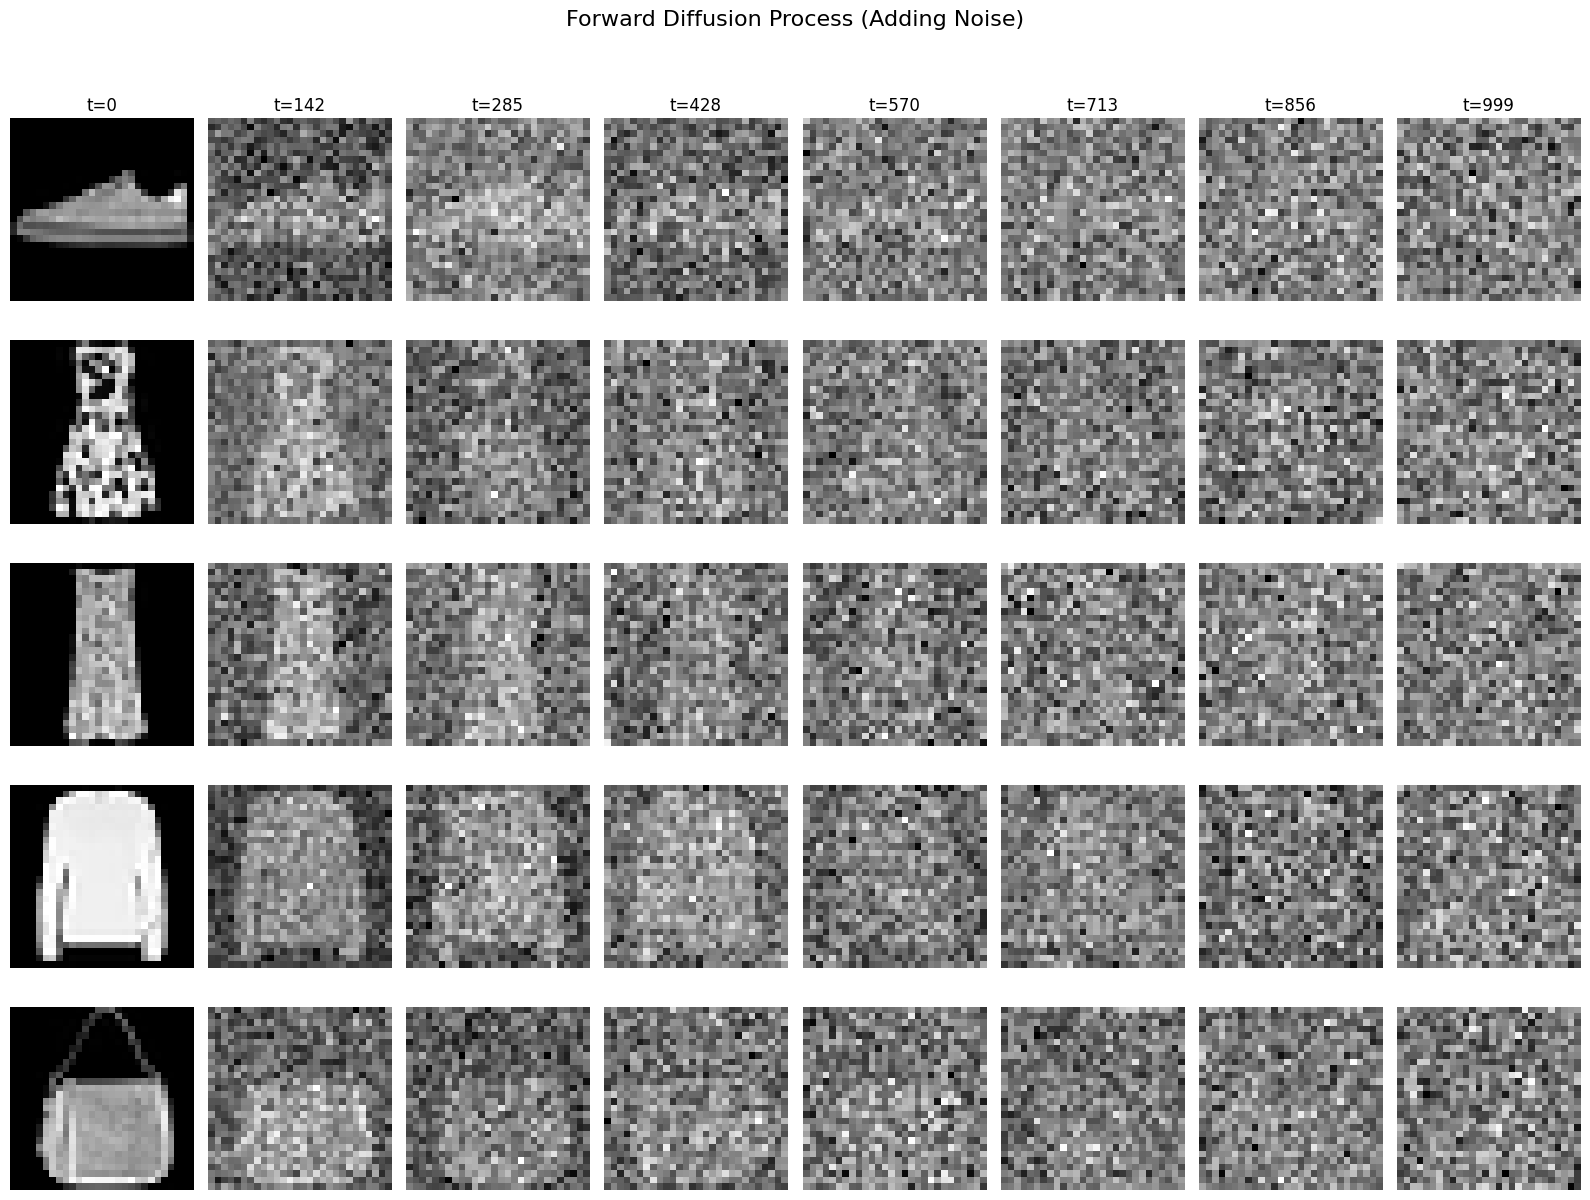

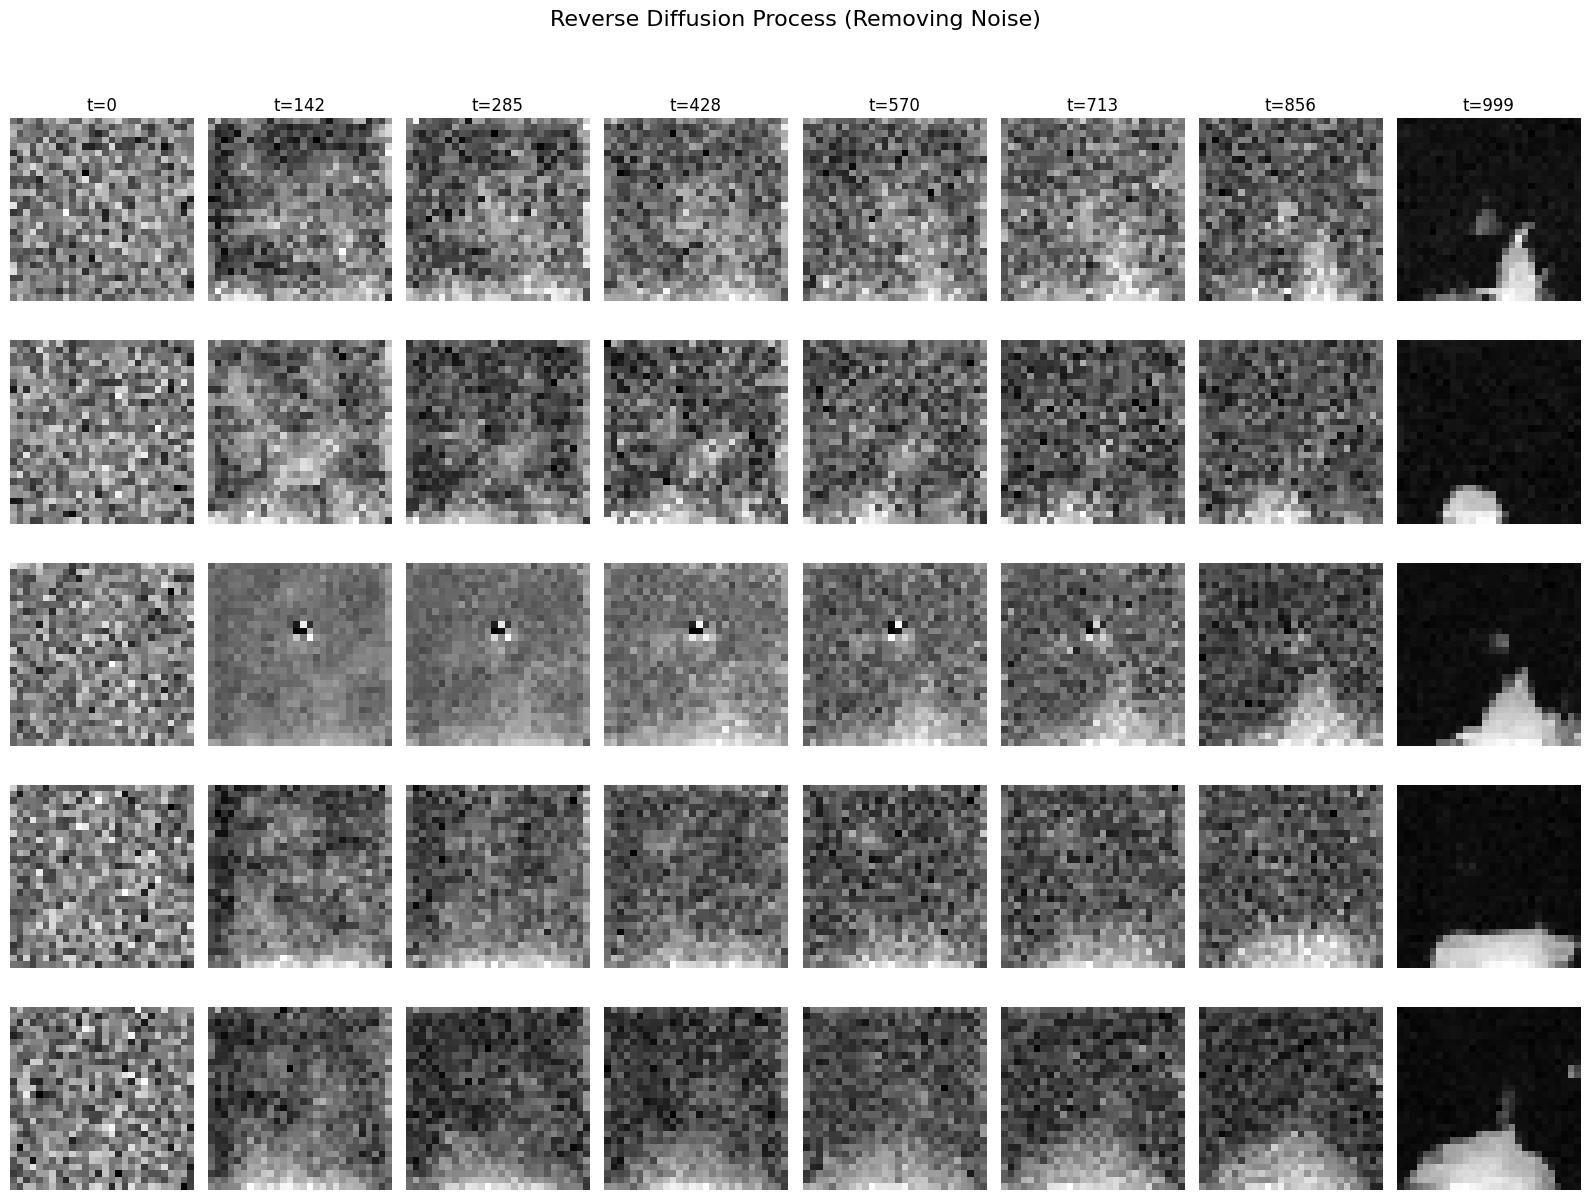

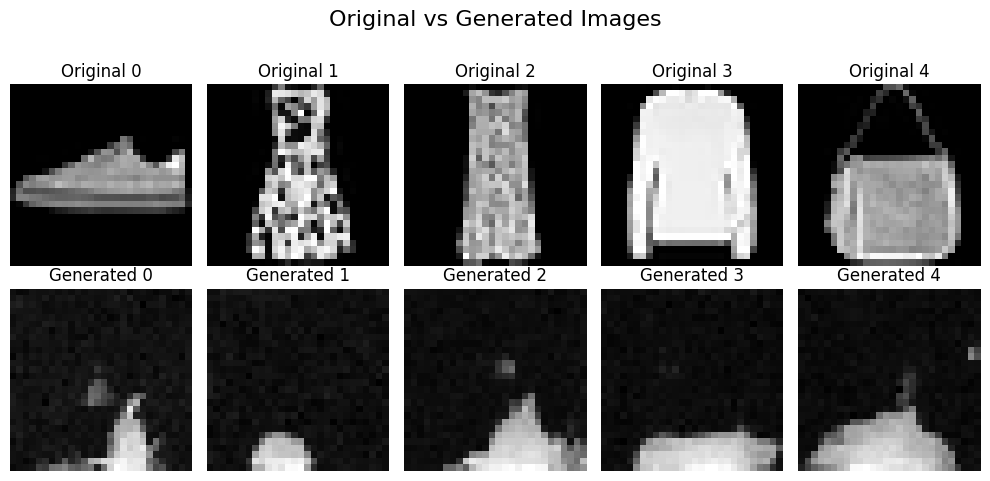

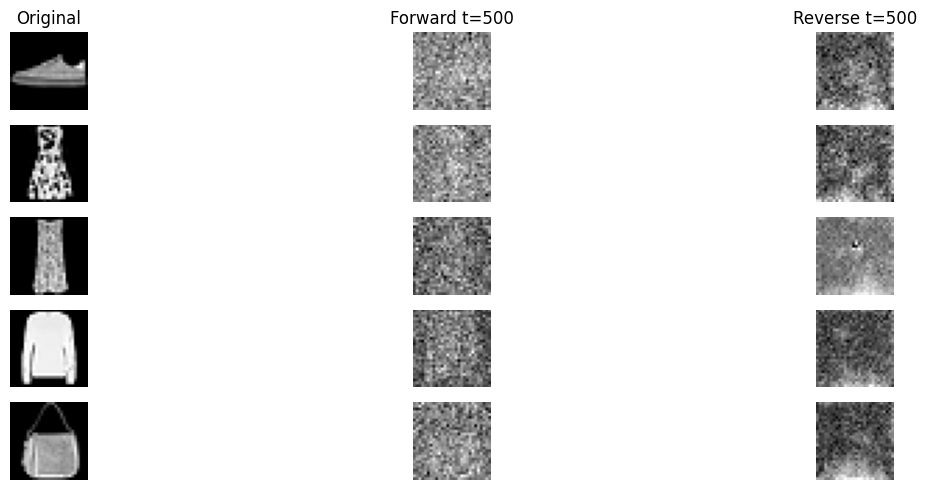

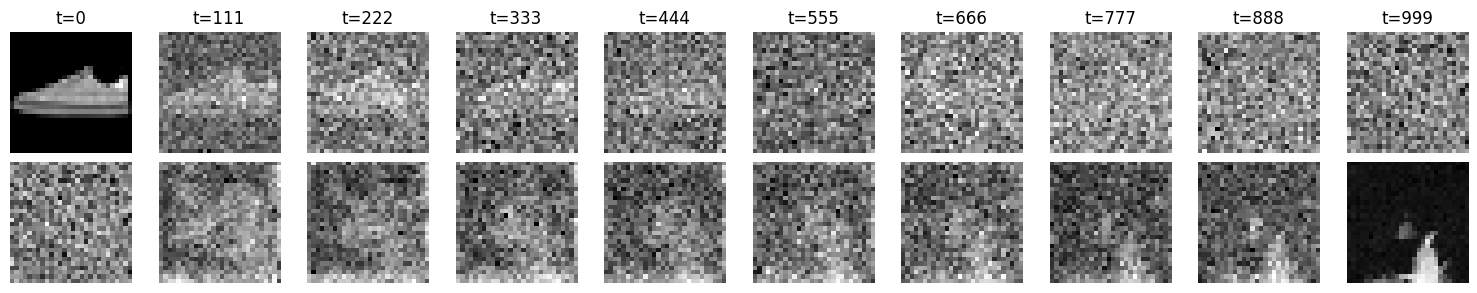

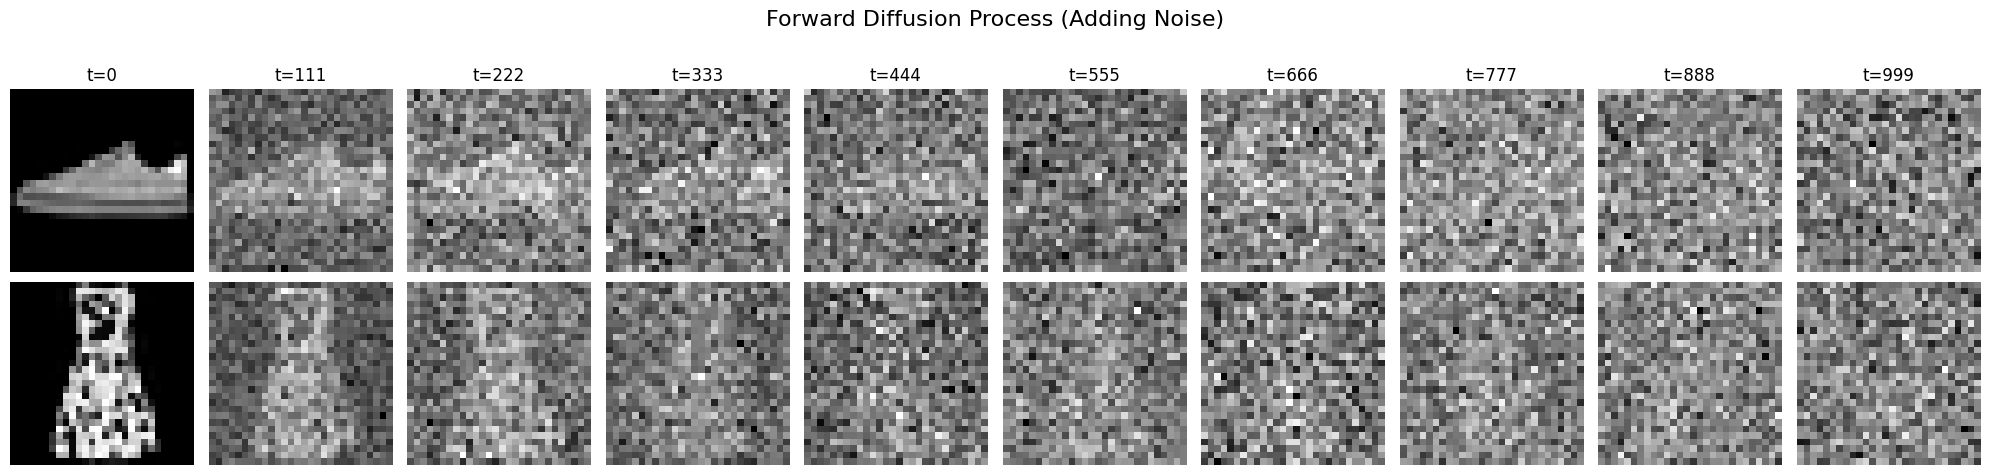

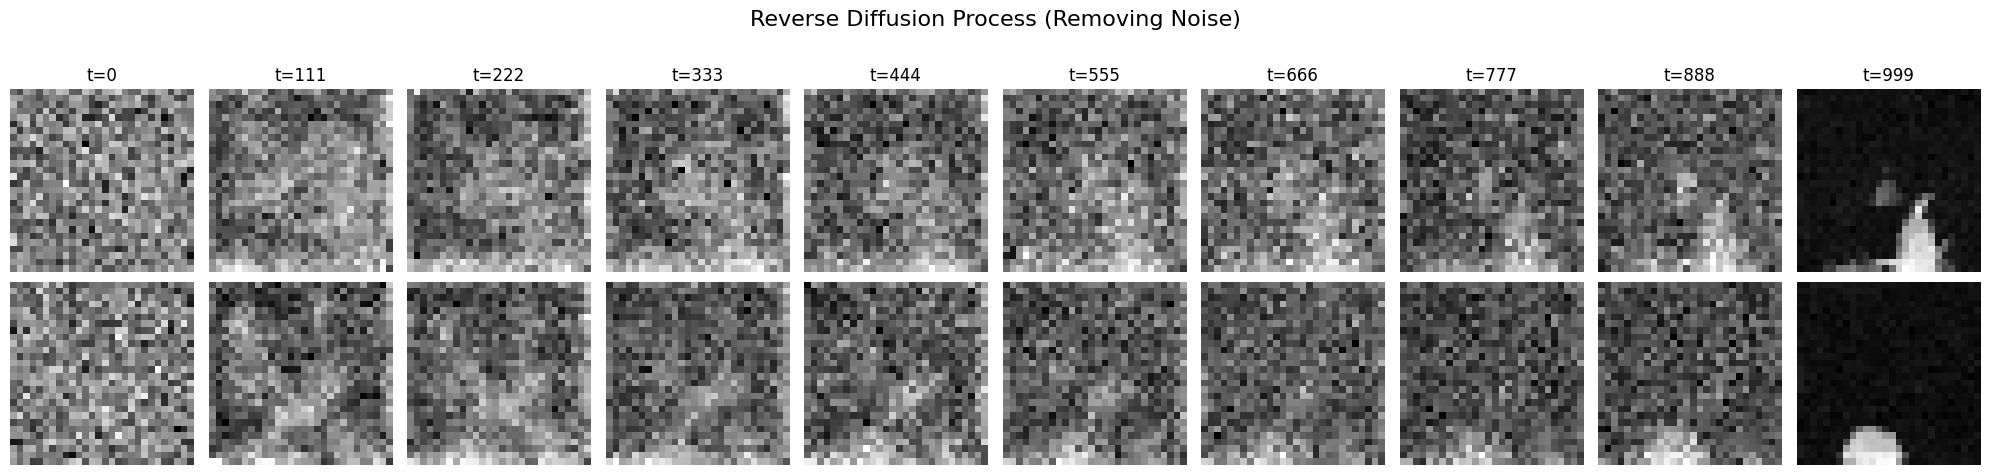

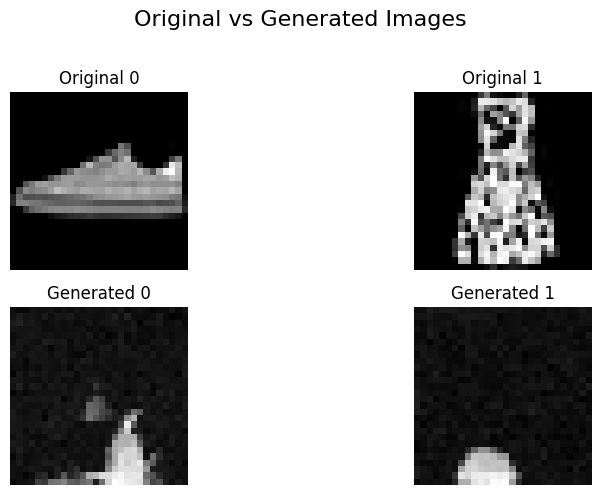

In [47]:
# 1. To view the entire diffusion progression for multiple images
plot_diffusion_images(f, r, image_indices=[0, 1, 2, 3, 4])

# 2. To view a specific timestep for several images
plot_diffusion_images(f, r, timestep=500, image_indices=[0, 1, 2, 3, 4]) 

# 3. To track the progression of a single image through the diffusion process
plot_single_image_progression(f, r, image_idx=0, num_steps=10)

# 4. To customize the grid layout for the progression view
plot_diffusion_images(f, r, image_indices=[0, 1], grid_size=(2, 10))